In [16]:
!pip -q install earthengine-api geemap
!pip -q install earthengine-api geemap pandas matplotlib seaborn scikit-learn

In [17]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ee.Authenticate()
ee.Initialize(project='ee-kirschenworks')

In [18]:
roi = ee.FeatureCollection('FAO/GAUL/2015/level1') \
    .filter(ee.Filter.eq('ADM0_NAME', 'Thailand')) \
    .filter(ee.Filter.eq('ADM1_NAME', 'Sukhothai'))

**training points**

In [24]:
training_points = ee.FeatureCollection('projects/ee-kirschenworks/assets/sukhothai_table_training_points')

In [25]:
def mask_s2(image):
    qa = image.select('QA60')
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(
        qa.bitwiseAnd(cirrus_bit_mask).eq(0)
    )
    return image.updateMask(mask).divide(10000)

s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterDate('2023-01-01', '2023-12-31')
      .filterBounds(roi)
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
      .map(mask_s2))

image = s2.median().clip(roi)

In [26]:
ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
ndwi = image.normalizedDifference(['B3', 'B8']).rename('NDWI')
ndbi = image.normalizedDifference(['B11', 'B8']).rename('NDBI')
bsi = image.expression(
    '((SWIR + RED) - (NIR + BLUE)) / ((SWIR + RED) + (NIR + BLUE))',
    {
        'SWIR': image.select('B11'),
        'RED': image.select('B4'),
        'NIR': image.select('B8'),
        'BLUE': image.select('B2')
    }
).rename('BSI')

img = image.addBands([ndvi, ndwi, ndbi, bsi])
bands = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDWI', 'NDBI', 'BSI']

**sample training data**

In [27]:
samples = img.select(bands).sampleRegions(
    collection=training_points,
    properties=['class'],
    scale=10,
    geometries=True
)

print('Sample count:', samples.size().getInfo())

Sample count: 400


**แบ่ง train / validation**

In [28]:
samples_random = samples.randomColumn('random', 42)

train = samples_random.filter(ee.Filter.lt('random', 0.8))
validation = samples_random.filter(ee.Filter.gte('random', 0.8))

print('Train size:', train.size().getInfo())
print('Validation size:', validation.size().getInfo())

Train size: 327
Validation size: 73


**train Random Forest**

In [29]:
rf = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
    features=train,
    classProperty='class',
    inputProperties=bands
)

classified = img.select(bands).classify(rf)

**accuracy assessment**

In [30]:
validated = validation.classify(rf)
conf_matrix = validated.errorMatrix('class', 'classification')

print('Confusion Matrix:', conf_matrix.getInfo())
print('Overall Accuracy:', conf_matrix.accuracy().getInfo())
print('Kappa:', conf_matrix.kappa().getInfo())
print('Producer Accuracy:', conf_matrix.producersAccuracy().getInfo())
print('User Accuracy:', conf_matrix.consumersAccuracy().getInfo())

Confusion Matrix: [[14, 0, 0, 1], [0, 21, 0, 0], [0, 0, 14, 4], [2, 2, 2, 13]]
Overall Accuracy: 0.8493150684931506
Kappa: 0.7980382293762575
Producer Accuracy: [[0.9333333333333333], [1], [0.7777777777777778], [0.6842105263157895]]
User Accuracy: [[0.875, 0.9130434782608695, 0.875, 0.7222222222222222]]


**feature importance**

In [31]:
importance = ee.Dictionary(rf.explain().get('importance')).getInfo()

importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values('Importance', ascending=False)

importance_df

,Feature,Importance
9,NDWI,73.304073
8,NDVI,63.720244
1,B12,61.589924
0,B11,60.152032
4,B4,59.029503
2,B2,57.988639
3,B3,56.641072
5,B8,54.146746
6,BSI,51.579687
7,NDBI,46.057433


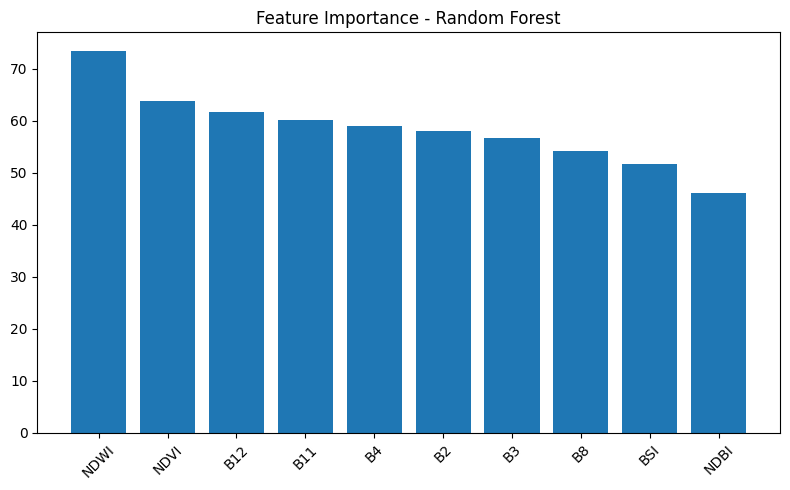

In [32]:
plt.figure(figsize=(8,5))
plt.bar(importance_df['Feature'], importance_df['Importance'])
plt.xticks(rotation=45)
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=200)
plt.show()

**confusion matrix**

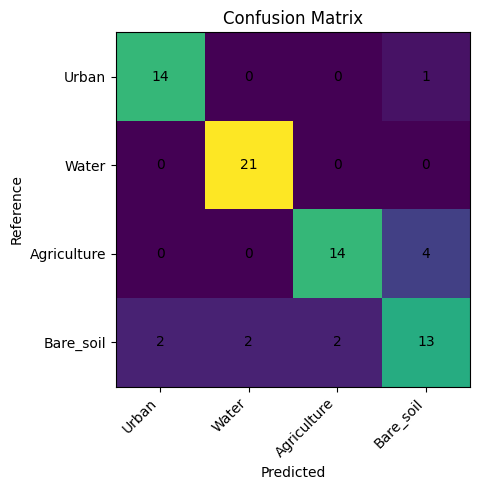

In [34]:
cm = np.array(conf_matrix.getInfo())
classes = ['Urban', 'Water', 'Agriculture', 'Bare_soil']

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm)

ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.set_yticklabels(classes)

for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, cm[i, j], ha='center', va='center')

ax.set_xlabel('Predicted')
ax.set_ylabel('Reference')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=200)
plt.show()

In [35]:
Map = geemap.Map(center=[17.0, 99.8], zoom=9)
Map.add_basemap('SATELLITE')
Map.addLayer(
    classified,
    {'min': 0, 'max': 3, 'palette': ['red', 'blue', 'green', 'yellow']},
    'RF Classification'
)
Map.addLayer(roi, {'color': 'black'}, 'ROI')
Map

Map(center=[17.0, 99.8], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(…